---------------------------------------------------------------------------------------------------------------
# Feature Importance
---------------------------------------------------------------------------------------------------------------
## Content log:
1. Import Libraries and setting paths
2. Loading Model
3. Recreate training features
4. Extract importance safely
5. Error Handling
6.  Plotting Feature Importance
7.  Key Observations
---------------------------------------------------------------------------------------------------------------

# 01. Import Libraries and setting paths

In [11]:
import sys
import os
sys.path.append(os.path.abspath("../../"))
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from src.target_engineering import create_target
os.makedirs("../../visuals_and_reports/modeling_analysis", exist_ok=True)

# 02. Loading Model

In [12]:
with open("../../models/best_model.pkl", "rb") as f:
    model = pickle.load(f)

# 03. Recreate training features

In [13]:
train = pd.read_csv("../../data/splits/train.csv")
train = create_target(train)
drop_cols = ["Date", "Ticker", "Returns", "Lag_1"]
X_train = train.drop("target", axis=1).drop(columns=drop_cols, errors="ignore")
feature_names = X_train.columns.tolist()
print("Features used:", feature_names)

Features used: ['Close', 'High', 'Low', 'Open', 'Volume', 'Ma_7', 'Ma_30', 'Volatility']


# 04. Extract importance safely

In [14]:
if hasattr(model, "feature_importances_"):
    importances = model.feature_importances_
elif hasattr(model, "coef_"):
    importances = model.coef_[0]
else:
    raise ValueError("Model does not support feature importance")

# 05. Error Handling

In [ ]:
assert len(importances) == len(feature_names), "Mismatch in features!"

# 06. Plotting Feature Importance

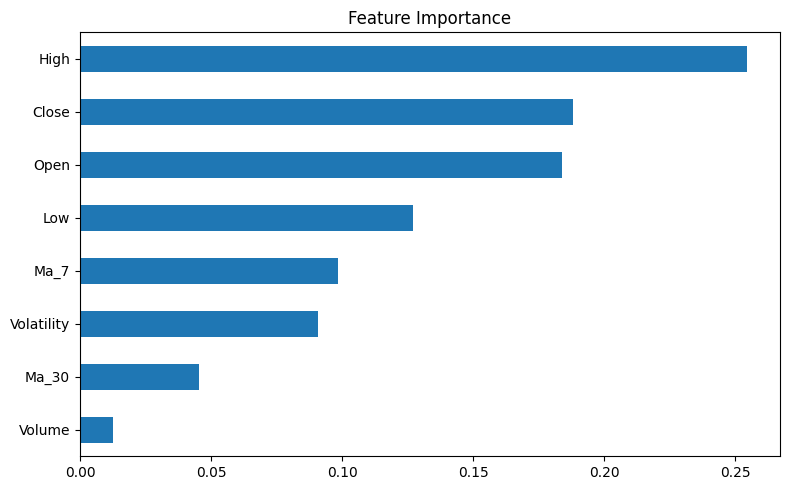

In [15]:
feat_imp = pd.Series(importances, index=feature_names)
feat_imp = feat_imp.sort_values()
feat_imp.plot(kind="barh", figsize=(8,5))
plt.title("Feature Importance")
plt.tight_layout()
plt.savefig("../../visuals_and_reports/modeling_analysis/feature_importance.png")
plt.show()

# 07. Key Observations
* The column(s) [High, Close, Open] holds maximum importance in the entire model training and matrix evaluation